In [1]:
!pip install -q segmentation-models-pytorch albumentations
!pip install -q transformers

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.3 MB/s eta 0:00:0000:01


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
Device: cuda


In [3]:
SPLITS_DIR = Path("/kaggle/input/datasets/ebyeager/splits")

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
valid_df = pd.read_csv(SPLITS_DIR / "valid_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

# Augmentation

import albumentations as A

IMAGE_HEIGHT = 384
IMAGE_WIDTH = 512

train_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=0,
        p=0.5
    ),

    A.OneOf([
        A.GaussNoise(p=1.0),
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
    ], p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

valid_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])


# PyTorch Dataset

from torch.utils.data import Dataset, DataLoader


class HumidityDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.loc[idx, "image"]
        mask_path = self.df.loc[idx, "mask"]

        # Read image
        image = np.array(Image.open(image_path).convert("RGB"))

        # Read mask
        mask = np.array(Image.open(mask_path).convert("L"))

        # Convert to binary
        mask = (mask > 0).astype(np.float32)

        # Albumentations
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # HWC -> CHW
        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        mask = torch.from_numpy(mask).float()

        # Add channel dimension
        mask = mask.unsqueeze(0)

        return image, mask


# DataLoaders

BATCH_SIZE = 8
NUM_WORKERS = 2

train_dataset = HumidityDataset(
    train_df,
    transform=train_transform
)

valid_dataset = HumidityDataset(
    valid_df,
    transform=valid_transform
)

test_dataset = HumidityDataset(
    test_df,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

def denormalize(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image.transpose(1, 2, 0)
    image = image * std + mean

    return np.clip(image, 0, 1)


# Metrics

def segmentation_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    """
    Compute batch-level binary segmentation metrics.
    """

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    masks = masks.float()

    predictions = predictions.view(predictions.size(0), -1)
    masks = masks.view(masks.size(0), -1)

    tp = (predictions * masks).sum(dim=1)
    fp = (predictions * (1 - masks)).sum(dim=1)
    fn = ((1 - predictions) * masks).sum(dim=1)

    dice = (
        (2 * tp + eps) /
        (2 * tp + fp + fn + eps)
    )

    iou = (
        (tp + eps) /
        (tp + fp + fn + eps)
    )

    precision = (
        (tp + eps) /
        (tp + fp + eps)
    )

    recall = (
        (tp + eps) /
        (tp + fn + eps)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }
    
# Loss functions

import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.view(
            probabilities.size(0), -1
        )

        targets = targets.view(
            targets.size(0), -1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probabilities.sum(dim=1)
                +
                targets.sum(dim=1)
                +
                self.smooth
            )
        )

        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5
    ):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss

criterion_deeplab = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

def segformer_loss(logits, masks):

    # Resize logits to ground-truth resolution
    logits = F.interpolate(
        logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Masks: [B, 1, H, W] -> [B, H, W]
    targets = masks.squeeze(1).long()

    # Cross Entropy
    ce_loss = F.cross_entropy(
        logits,
        targets
    )

    # Probability of humidity class
    probs = torch.softmax(
        logits,
        dim=1
    )[:, 1]

    targets_float = targets.float()

    smooth = 1e-6

    intersection = (
        probs * targets_float
    ).sum(dim=(1, 2))

    denominator = (
        probs.sum(dim=(1, 2))
        + targets_float.sum(dim=(1, 2))
    )

    dice = (
        (2 * intersection + smooth)
        / (denominator + smooth)
    ).mean()

    dice_loss = 1 - dice

    return (
        0.5 * ce_loss
        + 0.5 * dice_loss
    )


criterion = segformer_loss
# DeepLab Loader

def load_deeplab_model(model, checkpoint_path, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    print("Loaded:", checkpoint_path)
    print("Best epoch:", checkpoint["epoch"])
    print(
        "Best validation Dice:",
        checkpoint["best_val_dice"]
    )

    return model

# Segformer Loader

def load_segformer_model(model, checkpoint_path, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    print("Loaded:", checkpoint_path)
    print("Best epoch:", checkpoint["epoch"])
    print(
        "Best validation Dice:",
        checkpoint["best_val_dice"]
    )

    return model

DEEPLAB_R50_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth"
)

SEGFORMER_B0_CHECKPOINT = Path("/kaggle/input/datasets/ebyeager/results/segformer_mit_b0_best.pth"
)

SEGFORMER_B1_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/segformer_mit_b1_best.pth"
)

# ReCreating architectures
deeplab_r50 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

segformer_b0 = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2,
    ignore_mismatched_sizes=True
)

segformer_b1 = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b1",
    num_labels=2,
    ignore_mismatched_sizes=True
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

deeplab_r50 = load_deeplab_model(
    deeplab_r50,
    DEEPLAB_R50_CHECKPOINT,
    DEVICE
)

segformer_b0 = load_segformer_model(
    segformer_b0,
    SEGFORMER_B0_CHECKPOINT,
    DEVICE
)

segformer_b1 = load_segformer_model(
    segformer_b1,
    SEGFORMER_B1_CHECKPOINT,
    DEVICE
)


# Validation epoch functions

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    metric_totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }
    for images, masks in loader:
        images = images.to(
            device,
            non_blocking=True
        )
        masks = masks.to(
            device,
            non_blocking=True
        )
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = criterion(
                logits,
                masks
            )
        batch_size = images.size(0)
        running_loss += (
            loss.item() * batch_size
        )
        metrics = segmentation_metrics(
            logits,
            masks
        )
        for key in metric_totals:
            metric_totals[key] += (
                metrics[key] * batch_size
            )
        n_samples += batch_size
    results = {
        "loss": running_loss / n_samples
    }
    for key in metric_totals:
        results[key] = (
            metric_totals[key] / n_samples
        )
    return results


@torch.no_grad()
def validate_one_epoch_segformer(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    num_batches = 0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        targets = masks.squeeze(1).long()
        outputs = model(images)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        loss = criterion(
            logits,
            masks
        )
        predictions = torch.argmax(
            logits,
            dim=1
        )
        pred = predictions.float()
        target = targets.float()
        pred_flat = pred.view(pred.shape[0], -1)
        target_flat = target.view(target.shape[0], -1)
        tp = (
            pred_flat * target_flat
        ).sum(dim=1)
        fp = (
            pred_flat * (1 - target_flat)
        ).sum(dim=1)
        fn = (
            (1 - pred_flat) * target_flat
        ).sum(dim=1)
        eps = 1e-7
        dice = (
            (2 * tp + eps) /
            (2 * tp + fp + fn + eps)
        )
        iou = (
            (tp + eps) /
            (tp + fp + fn + eps)
        )
        precision = (
            (tp + eps) /
            (tp + fp + eps)
        )
        recall = (
            (tp + eps) /
            (tp + fn + eps)
        )
        total_loss += loss.item()
        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        total_precision += precision.mean().item()
        total_recall += recall.mean().item()
        num_batches += 1
    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches
    }

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

...

pytorch_model.bin:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/54.7M [00:00<?, ?B/s]

Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Loaded: /kaggle/input/datasets/ebyeager/results/segformer_mit_b0_best.pth
Best epoch: 14
Best validation Dice: 0.8373637056350708
Loaded: /kaggle/input/datasets/ebyeager/results/segformer_mit_b1_best.pth
Best epoch: 26
Best validation Dice: 0.8484352397918701


In [4]:
# ============================================================
# COLLECT VALIDATION PROBABILITY MAPS
# ============================================================

@torch.no_grad()
def collect_deeplab_predictions(
    model,
    loader,
    device
):
    model.eval()

    all_probs = []
    all_masks = []

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.float().cpu()
        )

        all_masks.append(
            masks.cpu()
        )

    return (
        torch.cat(all_probs, dim=0),
        torch.cat(all_masks, dim=0)
    )


@torch.no_grad()
def collect_segformer_predictions(
    model,
    loader,
    device
):
    model.eval()

    all_probs = []
    all_masks = []

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        probs = torch.softmax(
            logits,
            dim=1
        )[:, 1:2]

        all_probs.append(
            probs.float().cpu()
        )

        all_masks.append(
            masks.cpu()
        )

    return (
        torch.cat(all_probs, dim=0),
        torch.cat(all_masks, dim=0)
    )


print("=" * 70)
print("COLLECTING VALIDATION PREDICTIONS")
print("=" * 70)

r50_probs, val_masks = collect_deeplab_predictions(
    deeplab_r50,
    valid_loader,
    DEVICE
)

b0_probs, _ = collect_segformer_predictions(
    segformer_b0,
    valid_loader,
    DEVICE
)

b1_probs, _ = collect_segformer_predictions(
    segformer_b1,
    valid_loader,
    DEVICE
)

print("R50 probabilities :", r50_probs.shape)
print("B0 probabilities  :", b0_probs.shape)
print("B1 probabilities  :", b1_probs.shape)
print("Validation masks  :", val_masks.shape)

COLLECTING VALIDATION PREDICTIONS
R50 probabilities : torch.Size([194, 1, 384, 512])
B0 probabilities  : torch.Size([194, 1, 384, 512])
B1 probabilities  : torch.Size([194, 1, 384, 512])
Validation masks  : torch.Size([194, 1, 384, 512])


In [5]:
# ============================================================
# SANITY CHECK
# ============================================================

assert r50_probs.shape == b0_probs.shape
assert r50_probs.shape == b1_probs.shape
assert r50_probs.shape == val_masks.shape

assert torch.isfinite(r50_probs).all()
assert torch.isfinite(b0_probs).all()
assert torch.isfinite(b1_probs).all()

print("All prediction tensors are aligned and valid.")
print()
print("R50 range:",
      r50_probs.min().item(),
      "→",
      r50_probs.max().item())

print("B0 range:",
      b0_probs.min().item(),
      "→",
      b0_probs.max().item())

print("B1 range:",
      b1_probs.min().item(),
      "→",
      b1_probs.max().item())

All prediction tensors are aligned and valid.

R50 range: 3.066444396581519e-13 → 1.0
B0 range: 1.2564289875172108e-07 → 0.9999960660934448
B1 range: 7.301286658600858e-11 → 0.9999998807907104


In [6]:
# ============================================================
# MODEL COMPLEMENTARITY ANALYSIS
# ============================================================

def binary_predictions(probs, threshold=0.5):
    return (probs >= threshold).float()


r50_pred = binary_predictions(r50_probs)
b0_pred  = binary_predictions(b0_probs)
b1_pred  = binary_predictions(b1_probs)


# ------------------------------------------------------------
# Pairwise prediction agreement
# ------------------------------------------------------------

def agreement(pred_a, pred_b):
    return (
        (pred_a == pred_b)
        .float()
        .mean()
        .item()
    )


print("=" * 70)
print("PAIRWISE PREDICTION AGREEMENT")
print("=" * 70)

print(
    f"R50 ↔ B0 : {agreement(r50_pred, b0_pred):.4f}"
)

print(
    f"R50 ↔ B1 : {agreement(r50_pred, b1_pred):.4f}"
)

print(
    f"B0  ↔ B1 : {agreement(b0_pred, b1_pred):.4f}"
)


# ------------------------------------------------------------
# Pairwise disagreement
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PAIRWISE DISAGREEMENT")
print("=" * 70)

print(
    f"R50 ↔ B0 : "
    f"{1 - agreement(r50_pred, b0_pred):.4f}"
)

print(
    f"R50 ↔ B1 : "
    f"{1 - agreement(r50_pred, b1_pred):.4f}"
)

print(
    f"B0  ↔ B1 : "
    f"{1 - agreement(b0_pred, b1_pred):.4f}"
)


# ------------------------------------------------------------
# Error disagreement
# ------------------------------------------------------------

def error_mask(pred, target):
    return pred != target


r50_error = error_mask(r50_pred, val_masks)
b0_error  = error_mask(b0_pred, val_masks)
b1_error  = error_mask(b1_pred, val_masks)


def error_overlap(error_a, error_b):
    both_wrong = (
        error_a & error_b
    ).float().mean()

    either_wrong = (
        error_a | error_b
    ).float().mean()

    return (
        both_wrong.item(),
        either_wrong.item()
    )


print("\n" + "=" * 70)
print("ERROR COMPLEMENTARITY")
print("=" * 70)

for name_a, err_a, name_b, err_b in [
    ("R50", r50_error, "B0", b0_error),
    ("R50", r50_error, "B1", b1_error),
    ("B0",  b0_error,  "B1", b1_error),
]:

    both, either = error_overlap(
        err_a,
        err_b
    )

    print(
        f"{name_a} ↔ {name_b} | "
        f"Both wrong: {both:.4f} | "
        f"Either wrong: {either:.4f}"
    )

PAIRWISE PREDICTION AGREEMENT
R50 ↔ B0 : 0.9678
R50 ↔ B1 : 0.9699
B0  ↔ B1 : 0.9750

PAIRWISE DISAGREEMENT
R50 ↔ B0 : 0.0322
R50 ↔ B1 : 0.0301
B0  ↔ B1 : 0.0250

ERROR COMPLEMENTARITY
R50 ↔ B0 | Both wrong: 0.0359 | Either wrong: 0.0680
R50 ↔ B1 | Both wrong: 0.0358 | Either wrong: 0.0659
B0 ↔ B1 | Both wrong: 0.0401 | Either wrong: 0.0651


# Simple Probability Averaging: 

$$P_{\mathrm{ens}} = \frac{P_{R50} + P_{B0} + P_{B1}}{3}$$

In [7]:
# ============================================================
# SIMPLE PROBABILITY AVERAGING
# ============================================================

ensemble_probs = (
    r50_probs
    + b0_probs
    + b1_probs
) / 3.0

print("=" * 70)
print("SIMPLE ENSEMBLE")
print("=" * 70)

print("Ensemble shape:", ensemble_probs.shape)
print(
    "Probability range:",
    ensemble_probs.min().item(),
    "→",
    ensemble_probs.max().item()
)

SIMPLE ENSEMBLE
Ensemble shape: torch.Size([194, 1, 384, 512])
Probability range: 1.989238853639108e-07 → 0.9999914169311523


In [8]:
# ============================================================
# ENSEMBLE THRESHOLD SWEEP — VALIDATION
# ============================================================

def evaluate_probability_map(
    probabilities,
    masks,
    threshold=0.5,
    eps=1e-7
):

    predictions = (
        probabilities >= threshold
    ).float()

    predictions = predictions.view(
        predictions.size(0), -1
    )

    masks = masks.float().view(
        masks.size(0), -1
    )

    tp = (
        predictions * masks
    ).sum(dim=1)

    fp = (
        predictions * (1 - masks)
    ).sum(dim=1)

    fn = (
        (1 - predictions) * masks
    ).sum(dim=1)

    dice = (
        (2 * tp + eps)
        /
        (2 * tp + fp + fn + eps)
    )

    iou = (
        (tp + eps)
        /
        (tp + fp + fn + eps)
    )

    precision = (
        (tp + eps)
        /
        (tp + fp + eps)
    )

    recall = (
        (tp + eps)
        /
        (tp + fn + eps)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }


thresholds = np.arange(
    0.20,
    0.801,
    0.025
)

ensemble_results = []

for threshold in thresholds:

    metrics = evaluate_probability_map(
        ensemble_probs,
        val_masks,
        threshold=threshold
    )

    ensemble_results.append({
        "threshold": threshold,
        **metrics
    })


ensemble_results_df = pd.DataFrame(
    ensemble_results
)

print("=" * 70)
print("ENSEMBLE THRESHOLD SWEEP")
print("=" * 70)

print(
    ensemble_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


best_idx = ensemble_results_df[
    "dice"
].idxmax()

best_ensemble = ensemble_results_df.loc[
    best_idx
]

print("\n" + "=" * 70)
print("BEST SIMPLE ENSEMBLE")
print("=" * 70)

print(
    f"Threshold : "
    f"{best_ensemble['threshold']:.3f}"
)

print(
    f"Dice      : "
    f"{best_ensemble['dice']:.4f}"
)

print(
    f"IoU       : "
    f"{best_ensemble['iou']:.4f}"
)

print(
    f"Precision : "
    f"{best_ensemble['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_ensemble['recall']:.4f}"
)

ENSEMBLE THRESHOLD SWEEP
 threshold   dice    iou  precision  recall
    0.2000 0.8306 0.7437     0.7936  0.9334
    0.2250 0.8335 0.7474     0.8003  0.9302
    0.2500 0.8363 0.7511     0.8068  0.9271
    0.2750 0.8390 0.7545     0.8132  0.9239
    0.3000 0.8416 0.7578     0.8198  0.9204
    0.3250 0.8439 0.7609     0.8264  0.9167
    0.3500 0.8460 0.7636     0.8330  0.9126
    0.3750 0.8473 0.7654     0.8384  0.9088
    0.4000 0.8486 0.7671     0.8436  0.9050
    0.4250 0.8497 0.7684     0.8484  0.9014
    0.4500 0.8505 0.7695     0.8528  0.8978
    0.4750 0.8512 0.7703     0.8572  0.8941
    0.5000 0.8516 0.7709     0.8613  0.8904
    0.5250 0.8519 0.7712     0.8655  0.8864
    0.5500 0.8521 0.7713     0.8697  0.8822
    0.5750 0.8521 0.7713     0.8740  0.8776
    0.6000 0.8518 0.7710     0.8785  0.8725
    0.6250 0.8512 0.7703     0.8833  0.8666
    0.6500 0.8493 0.7679     0.8877  0.8590
    0.6750 0.8449 0.7624     0.8917  0.8478
    0.7000 0.8427 0.7597     0.8956  0.8410
    0.7

# Weighted ensemble search

In [9]:
# ======================================================================
# WEIGHTED ENSEMBLE SEARCH — VALIDATION SET
# ======================================================================

import itertools
print("=" * 70)
print("WEIGHTED ENSEMBLE SEARCH")
print("=" * 70)

# ----------------------------------------------------------------------
# Candidate weights
# ----------------------------------------------------------------------

candidate_weights = [
    (1/3, 1/3, 1/3),  # Equal ensemble

    (0.2, 0.2, 0.6),
    (0.2, 0.3, 0.5),
    (0.3, 0.2, 0.5),

    (0.2, 0.4, 0.4),
    (0.3, 0.3, 0.4),
    (0.4, 0.2, 0.4),

    (0.3, 0.4, 0.3),
    (0.4, 0.3, 0.3),
    (0.4, 0.4, 0.2),

    (0.1, 0.3, 0.6),
    (0.1, 0.4, 0.5),
    (0.3, 0.1, 0.6),
    (0.4, 0.1, 0.5),
]

thresholds = torch.arange(
    0.20,
    0.801,
    0.025
)

weighted_results = []

for w_r50, w_b0, w_b1 in candidate_weights:

    # Weighted probability averaging
    ensemble_probs = (
        w_r50 * r50_probs
        + w_b0 * b0_probs
        + w_b1 * b1_probs
    )

    best_result = None

    for threshold in thresholds:

        metrics = segmentation_metrics(
            ensemble_probs,
            val_masks,
            threshold=float(threshold)
        )

        result = {
            "w_r50": w_r50,
            "w_b0": w_b0,
            "w_b1": w_b1,
            "threshold": float(threshold),
            **metrics
        }

        if (
            best_result is None
            or result["dice"] > best_result["dice"]
        ):
            best_result = result

    weighted_results.append(best_result)


weighted_results_df = pd.DataFrame(
    weighted_results
).sort_values(
    "dice",
    ascending=False
).reset_index(drop=True)


print("\nBEST RESULT FOR EACH WEIGHTING:\n")

print(
    weighted_results_df[
        [
            "w_r50",
            "w_b0",
            "w_b1",
            "threshold",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ].to_string(index=False)
)

WEIGHTED ENSEMBLE SEARCH

BEST RESULT FOR EACH WEIGHTING:

   w_r50     w_b0     w_b1  threshold     dice      iou  precision   recall
0.300000 0.300000 0.400000      0.625 0.852489 0.771959   0.864544 0.888481
0.400000 0.200000 0.400000      0.625 0.852245 0.771765   0.866750 0.885790
0.200000 0.400000 0.400000      0.625 0.852101 0.771204   0.861987 0.890279
0.333333 0.333333 0.333333      0.625 0.851823 0.771059   0.863170 0.888708
0.400000 0.100000 0.500000      0.625 0.851812 0.771280   0.868606 0.883799
0.300000 0.200000 0.500000      0.625 0.851771 0.771059   0.866381 0.885947
0.200000 0.300000 0.500000      0.625 0.851559 0.770589   0.864350 0.887429
0.300000 0.400000 0.300000      0.625 0.851263 0.770177   0.861033 0.889850
0.400000 0.300000 0.300000      0.625 0.851175 0.770360   0.863885 0.886893
0.100000 0.400000 0.500000      0.625 0.851123 0.769745   0.862125 0.888736
0.300000 0.100000 0.600000      0.625 0.850706 0.769651   0.866478 0.884330
0.200000 0.200000 0.600000   

In [10]:
# ======================================================================
# BEST WEIGHTED ENSEMBLE
# ======================================================================

best_weighted = weighted_results_df.iloc[0]

print("=" * 70)
print("BEST WEIGHTED ENSEMBLE")
print("=" * 70)

print(f"R50 weight      : {best_weighted['w_r50']:.3f}")
print(f"B0 weight       : {best_weighted['w_b0']:.3f}")
print(f"B1 weight       : {best_weighted['w_b1']:.3f}")
print(f"Threshold       : {best_weighted['threshold']:.3f}")
print(f"Dice            : {best_weighted['dice']:.4f}")
print(f"IoU             : {best_weighted['iou']:.4f}")
print(f"Precision       : {best_weighted['precision']:.4f}")
print(f"Recall          : {best_weighted['recall']:.4f}")

print("\nReference — Equal ensemble:")
print("Weights         : 0.333 / 0.333 / 0.333")
print("Threshold       : 0.575")
print("Dice            : 0.8521")
print("IoU             : 0.7713")

BEST WEIGHTED ENSEMBLE
R50 weight      : 0.300
B0 weight       : 0.300
B1 weight       : 0.400
Threshold       : 0.625
Dice            : 0.8525
IoU             : 0.7720
Precision       : 0.8645
Recall          : 0.8885

Reference — Equal ensemble:
Weights         : 0.333 / 0.333 / 0.333
Threshold       : 0.575
Dice            : 0.8521
IoU             : 0.7713


# Test Evaluation

In [11]:
test_r50_probs, test_masks = collect_deeplab_predictions(
    deeplab_r50,
    test_loader,
    DEVICE
)

test_b0_probs, _ = collect_segformer_predictions(
    segformer_b0,
    test_loader,
    DEVICE
)

test_b1_probs, _ = collect_segformer_predictions(
    segformer_b1,
    test_loader,
    DEVICE
)

print("R50 probabilities :", test_r50_probs.shape)
print("B0 probabilities  :", test_b0_probs.shape)
print("B1 probabilities  :", test_b1_probs.shape)
print("Test masks        :", test_masks.shape)

assert test_r50_probs.shape == test_masks.shape
assert test_b0_probs.shape == test_masks.shape
assert test_b1_probs.shape == test_masks.shape

print("\nAll test prediction tensors are aligned and valid.")

R50 probabilities : torch.Size([195, 1, 384, 512])
B0 probabilities  : torch.Size([195, 1, 384, 512])
B1 probabilities  : torch.Size([195, 1, 384, 512])
Test masks        : torch.Size([195, 1, 384, 512])

All test prediction tensors are aligned and valid.


In [12]:
# ======================================================================
# FINAL FROZEN ENSEMBLE — TEST SET
# ======================================================================

R50_WEIGHT = 0.30
B0_WEIGHT = 0.30
B1_WEIGHT = 0.40

FINAL_THRESHOLD = 0.625

test_ensemble_probs = (
    R50_WEIGHT * test_r50_probs
    + B0_WEIGHT * test_b0_probs
    + B1_WEIGHT * test_b1_probs
)

print("=" * 70)
print("FINAL FROZEN ENSEMBLE")
print("=" * 70)

print(f"R50 weight : {R50_WEIGHT}")
print(f"B0 weight  : {B0_WEIGHT}")
print(f"B1 weight  : {B1_WEIGHT}")
print(f"Threshold  : {FINAL_THRESHOLD}")

print("\nEnsemble shape:", test_ensemble_probs.shape)
print(
    "Probability range:",
    test_ensemble_probs.min().item(),
    "→",
    test_ensemble_probs.max().item()
)

FINAL FROZEN ENSEMBLE
R50 weight : 0.3
B0 weight  : 0.3
B1 weight  : 0.4
Threshold  : 0.625

Ensemble shape: torch.Size([195, 1, 384, 512])
Probability range: 8.938617952480854e-07 → 0.9999966621398926


In [13]:
# ======================================================================
# FINAL ENSEMBLE — TEST RESULTS
# ======================================================================

final_test_metrics = segmentation_metrics(
    test_ensemble_probs,
    test_masks,
    threshold=FINAL_THRESHOLD
)

print("=" * 70)
print("FINAL ENSEMBLE — TEST RESULTS")
print("=" * 70)

print(f"Threshold   : {FINAL_THRESHOLD:.3f}")
print(f"Dice        : {final_test_metrics['dice']:.4f}")
print(f"IoU         : {final_test_metrics['iou']:.4f}")
print(f"Precision   : {final_test_metrics['precision']:.4f}")
print(f"Recall      : {final_test_metrics['recall']:.4f}")

FINAL ENSEMBLE — TEST RESULTS
Threshold   : 0.625
Dice        : 0.8504
IoU         : 0.7724
Precision   : 0.8668
Recall      : 0.8732


## Visualization

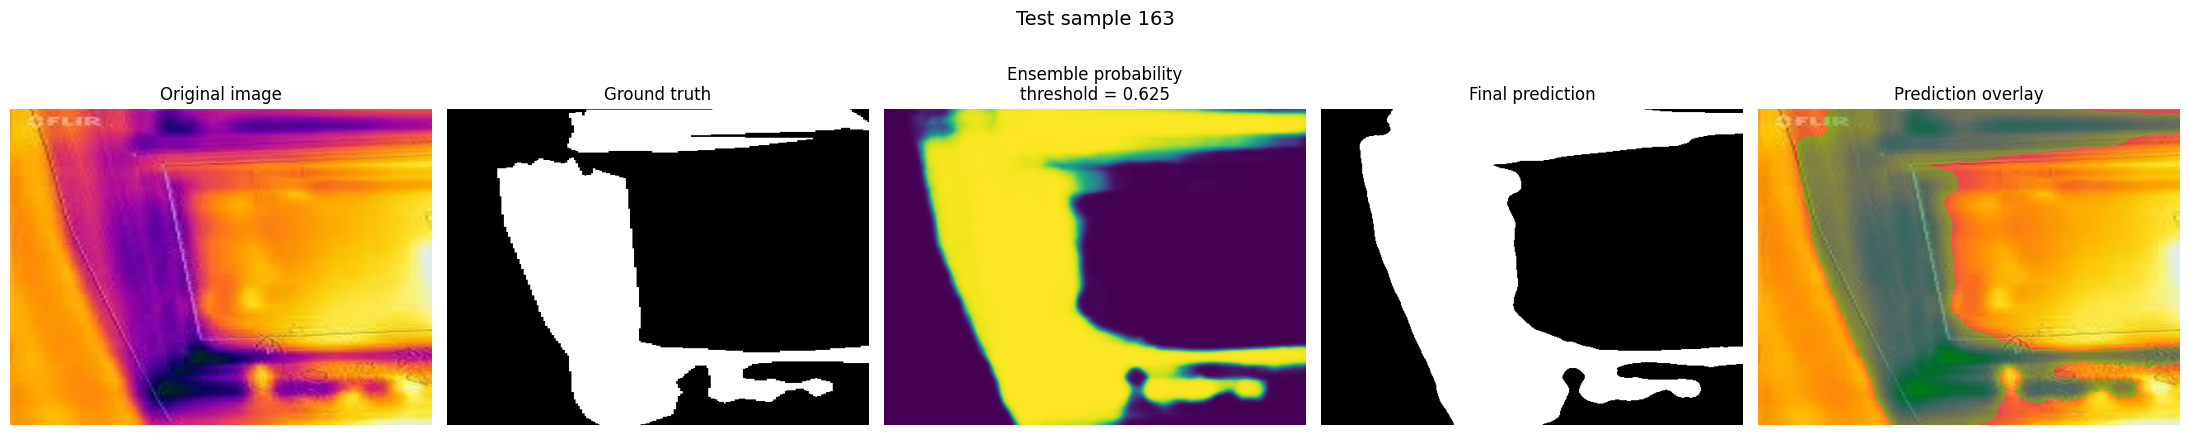

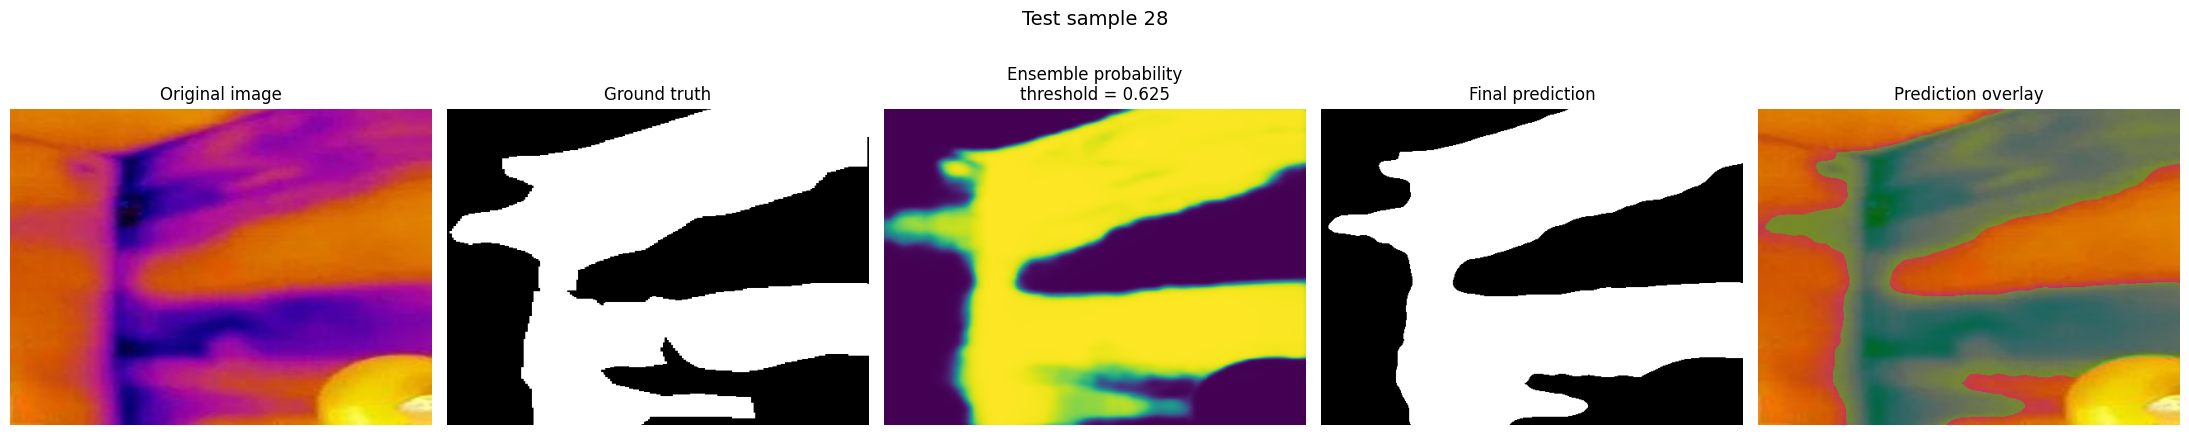

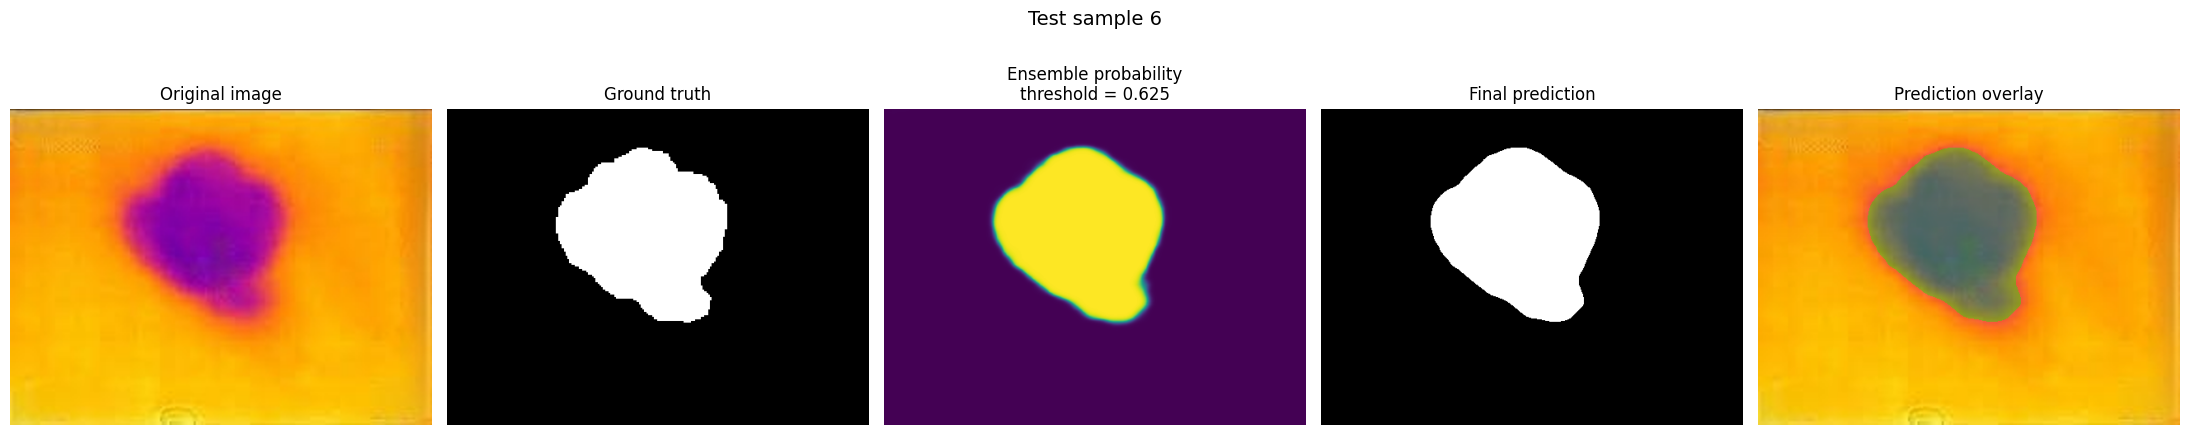

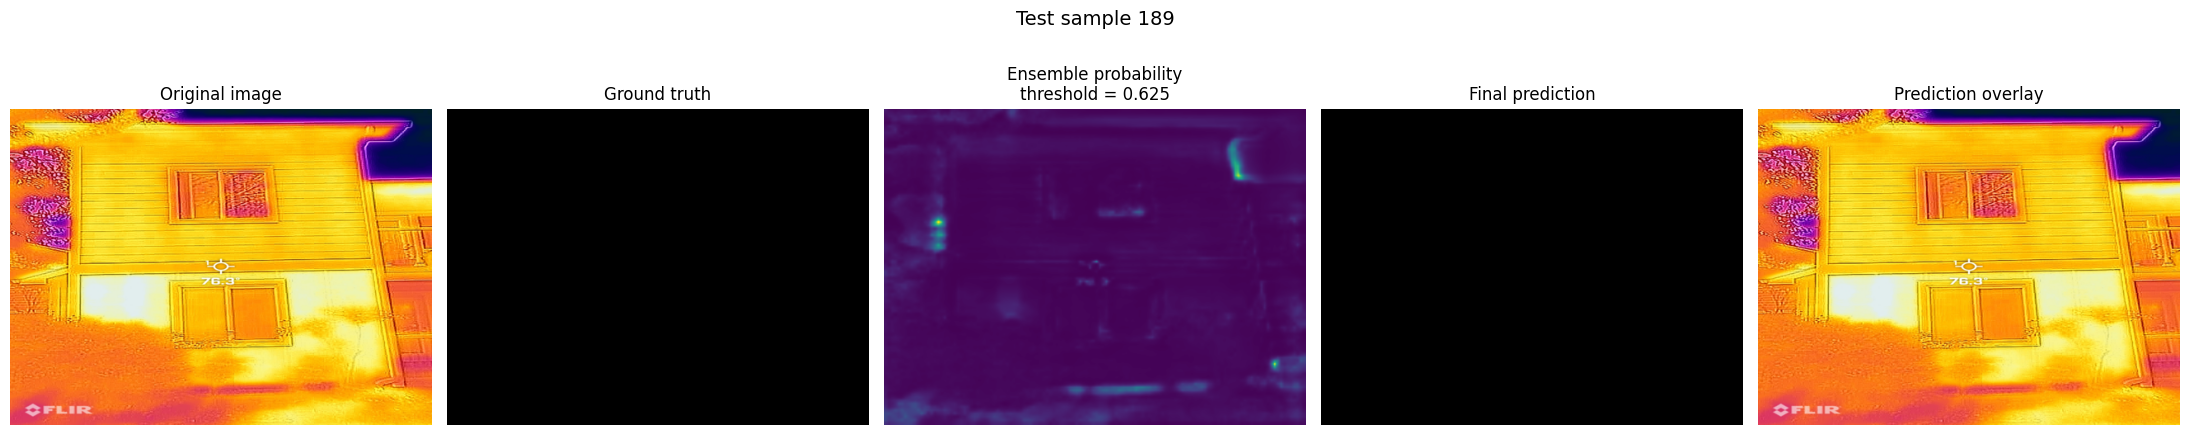

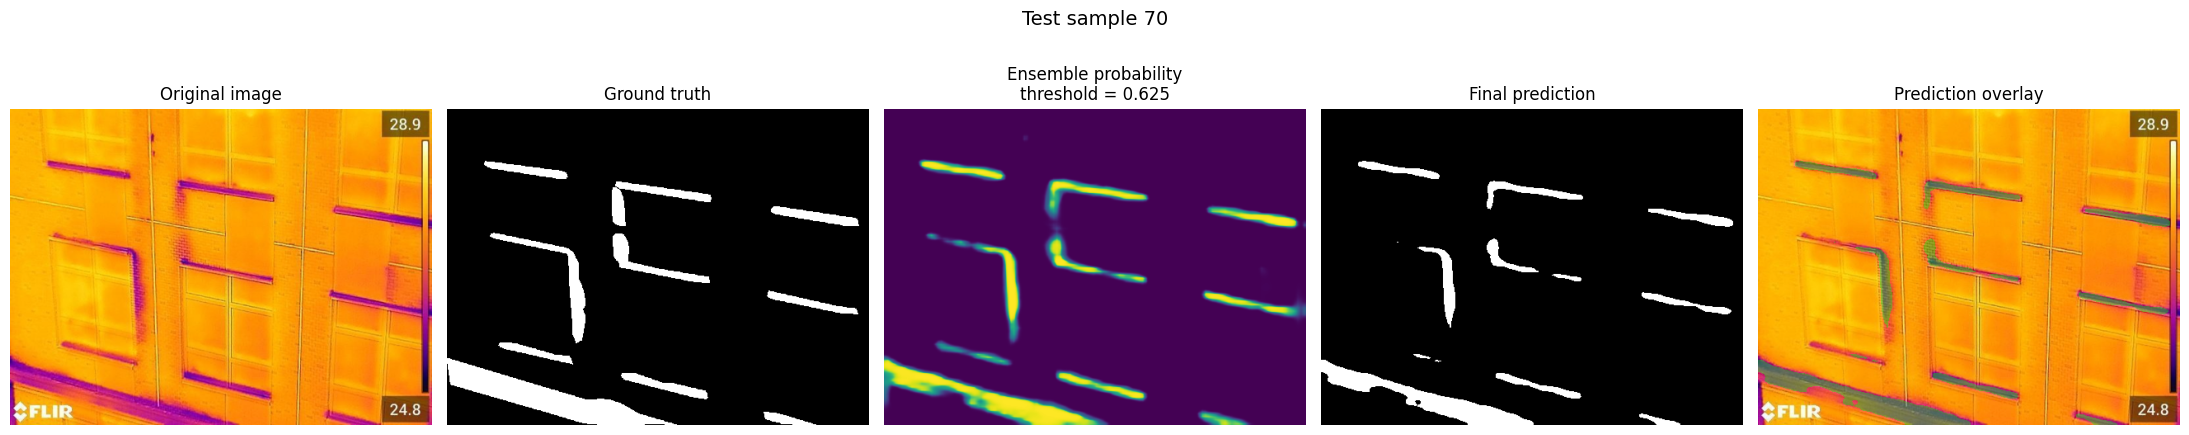

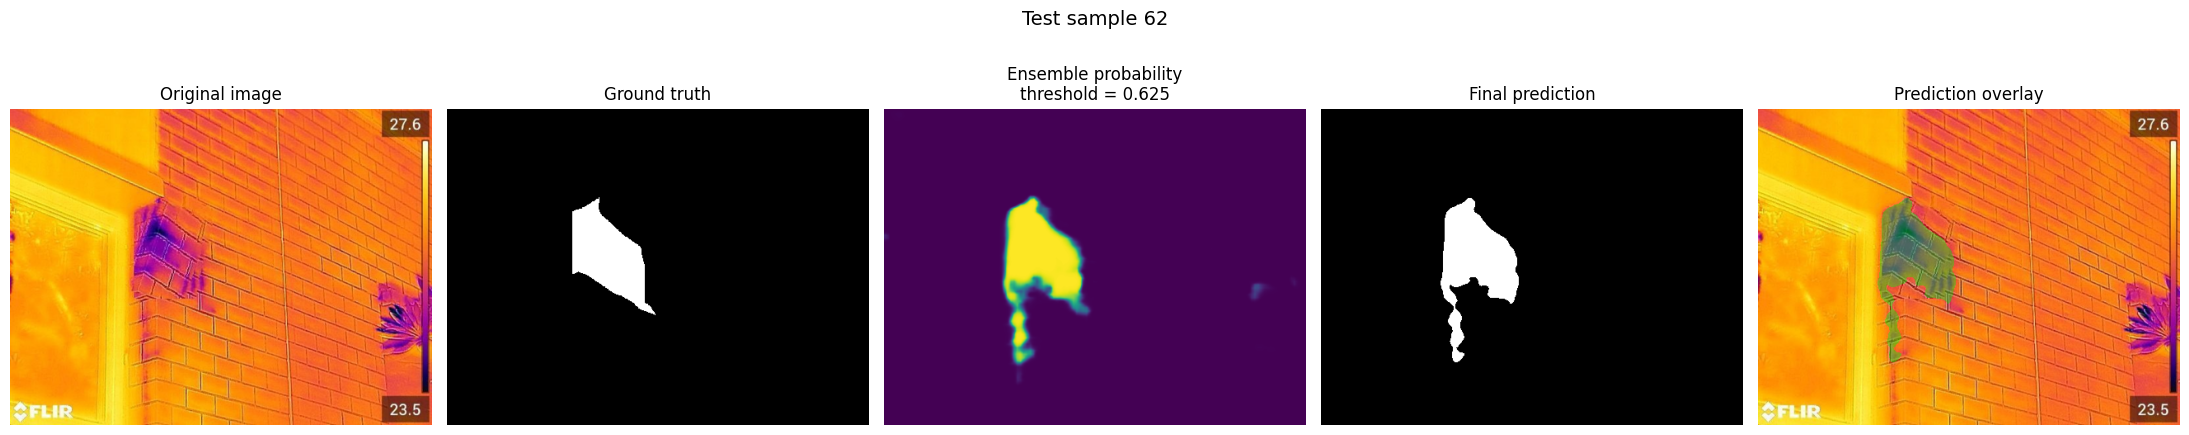

In [17]:
# ======================================================================
# VISUALIZE FINAL ENSEMBLE PREDICTIONS
# ======================================================================

import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Number of examples
N_SAMPLES = 6

# Random test samples
indices = random.sample(
    range(len(test_df)),
    min(N_SAMPLES, len(test_df))
)

# Frozen final ensemble settings
FINAL_THRESHOLD = 0.625

for idx in indices:

    # ------------------------------------------------------------
    # Load original image
    # ------------------------------------------------------------

    image_path = test_df.iloc[idx]["image"]

    original_image = np.array(
        Image.open(image_path).convert("RGB")
    )

    # ------------------------------------------------------------
    # Ground truth
    # ------------------------------------------------------------

    ground_truth = test_masks[idx].squeeze().numpy()

    # ------------------------------------------------------------
    # Ensemble probability
    # ------------------------------------------------------------

    probability = (
        test_ensemble_probs[idx]
        .squeeze()
        .numpy()
    )

    # ------------------------------------------------------------
    # Final binary prediction
    # ------------------------------------------------------------

    prediction = (
        probability >= FINAL_THRESHOLD
    ).astype(np.float32)

    # ------------------------------------------------------------
    # Resize original image to prediction resolution
    # ------------------------------------------------------------

    display_image = np.array(
        Image.fromarray(original_image).resize(
            (
                probability.shape[1],
                probability.shape[0]
            )
        )
    )

    # ------------------------------------------------------------
    # Create overlays
    # ------------------------------------------------------------

    gt_overlay = display_image.copy()
    pred_overlay = display_image.copy()

    # Ground truth in red
    gt_overlay[ground_truth > 0.5] = (
        0.6 * gt_overlay[ground_truth > 0.5]
        + 0.4 * np.array([255, 0, 0])
    )

    # Prediction in green
    pred_overlay[prediction > 0.5] = (
        0.6 * pred_overlay[prediction > 0.5]
        + 0.4 * np.array([0, 255, 0])
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(22, 5)
    )

    axes[0].imshow(display_image)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(ground_truth, cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    axes[2].imshow(probability, cmap="viridis")
    axes[2].set_title(
        f"Ensemble probability\nthreshold = {FINAL_THRESHOLD}"
    )
    axes[2].axis("off")

    axes[3].imshow(prediction, cmap="gray")
    axes[3].set_title("Final prediction")
    axes[3].axis("off")

    axes[4].imshow(pred_overlay)
    axes[4].set_title("Prediction overlay")
    axes[4].axis("off")

    plt.suptitle(
        f"Test sample {idx}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()